In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import sys
import pandas as pd

import cogwheel.cosmology
import cogwheel.data
import cogwheel.posterior
import cogwheel.sampling
import cogwheel.gw_plotting
import cogwheel.gw_utils
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors

import gwosc
import gwpy.table
from pesummary.io import read

import warnings
warnings.simplefilter("ignore", RuntimeWarning)

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
from helpers import load_event_data_and_posterior_samples, plot_posterior_samples

In [3]:
# load injection results

# load our posterior samples and the released samples from the LVK PE
resdir = '../data/pe_runs_lensing/injections/IntrinsicLVCPrior'
# get the results here
event_dir_list = glob.glob(f'{resdir}/GW*')
eventname_list = [
    event_dir.split('/')[-1] for event_dir in event_dir_list
]
print(f"found {len(eventname_list)} events")

found 11 events


In [5]:
# load the event data
eventname = 'GW22'
i = eventname_list.index(eventname)
event_data = cogwheel.data.EventData.from_npz(filename=os.path.join(event_dir_list[i], 'run_0', f'{eventname}.npz'))

In [6]:
event_data.injection

{'par_dic': {'f_ref': 100.0,
  'm1': 60,
  'm2': 20,
  's1z': 0.0,
  's2z': 0.0,
  'psi': 0.5,
  'iota': 1.4707963267948965,
  's1x_n': 0.0,
  's1y_n': 0.0,
  's2x_n': 0.0,
  's2y_n': 0.0,
  'ra': 3.0,
  'dec': -0.5,
  't_geocenter': 0.0,
  'phi_ref': 0.43867,
  'd_luminosity': 1000.0,
  'l1': 0.0,
  'l2': 0.0},
 'approximant': 'IMRPhenomXPHM',
 'd_h': array([113.90850488, 162.05204256,   0.77801877]),
 'h_h': array([110.04052608, 167.2238733 ,   1.49075237])}

In [7]:
rho = np.sqrt(np.sum(event_data.injection['h_h']))
rho

np.float64(16.69596213916447)

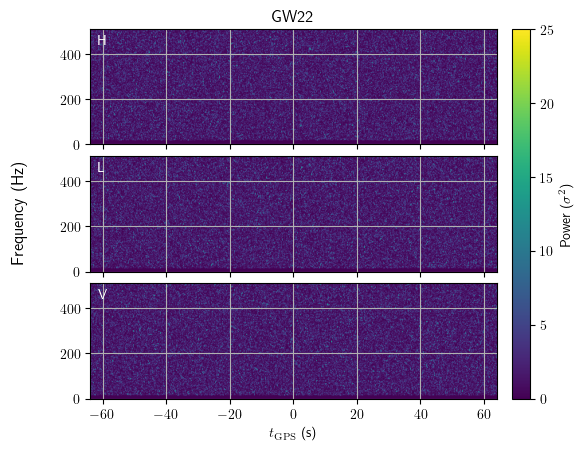

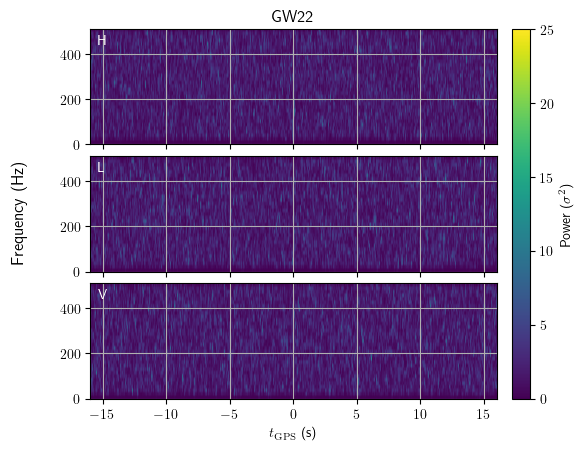

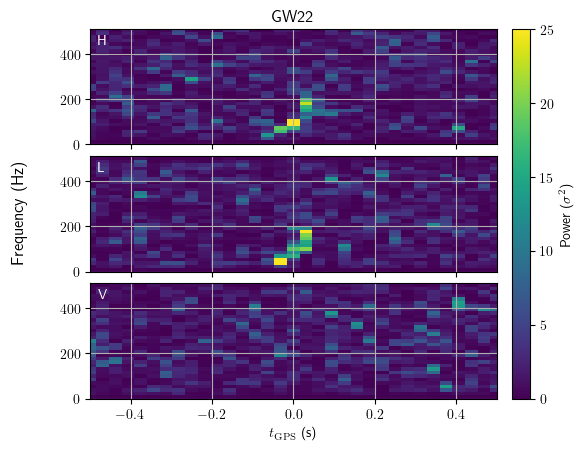

In [8]:
# check out the spectrogram
event_data.specgram(nfft=512)
kwargs = dict(
    fmax = 256,
    wht_filter_duration = 32,
    t_before = 32,
    t_after = 16
)
event_data.specgram(np.multiply(kwargs.get('wht_filter_duration', 32), (-.5, .5)))
event_data.specgram((-.5, .5))
plt.show()

In [9]:
# load the posterior samples
event_data, samples = load_event_data_and_posterior_samples(event_dir_list[i], eventname)

loaded posterior samples for GW22 run 0


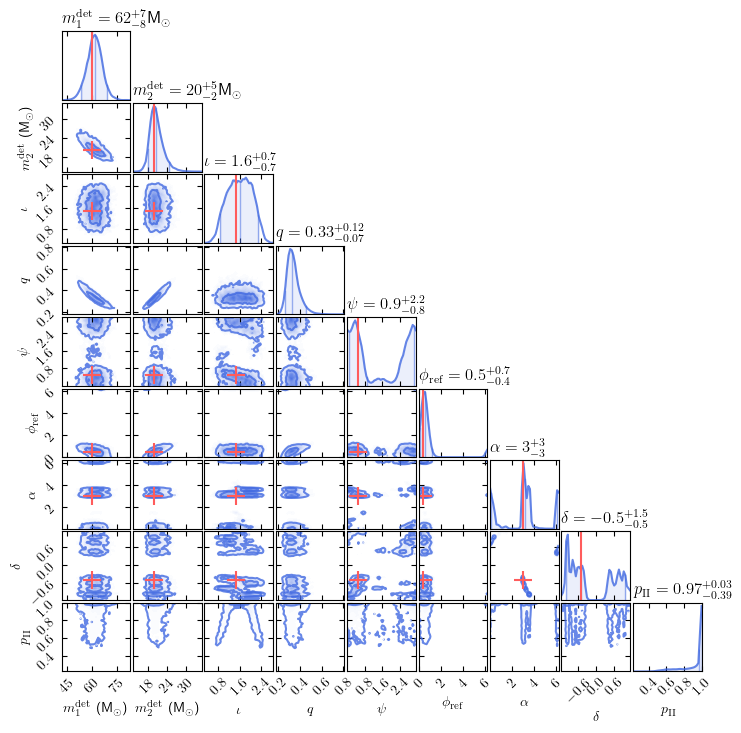

In [22]:
# plot parameters for our cogwheel results:
pars_to_plot = [
    'm1',
    'm2',
    'iota',
    'q',
    'psi',
    'phi_ref',
    'ra',
    'dec'
]
corner_plot = plot_posterior_samples(samples, event_data, plot_injected=True, pars_to_plot=pars_to_plot)

In [19]:
# compute Bayes factor and uncertainty
n_resamples = 1000
bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
# log these
lnbayes_factors = np.log(bayes_factors)
# get the median and standard deviation
lnbayes, lnbayes_std = np.median(lnbayes_factors), np.std(lnbayes_factors)
print(lnbayes, lnbayes_std)

2.1048012919255266 0.015582157642431253
